===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 n

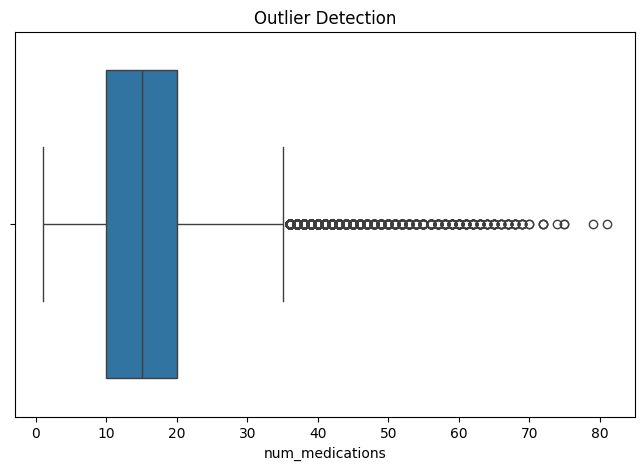


===== NORMALIZED DATA =====
   num_medications
0           0.0000
1           0.2125
2           0.1500
3           0.1875
4           0.0875

===== LABEL ENCODING =====
   gender
0       0
1       0
2       0
3       1
4       1

===== ONE HOT ENCODING =====
   AfricanAmerican  Asian  Caucasian  Hispanic  Other
0            False  False       True     False  False
1            False  False       True     False  False
2             True  False      False     False  False
3            False  False       True     False  False
4            False  False       True     False  False

===== DROP ROWS =====
Empty DataFrame
Columns: [encounter_id, patient_nbr, race, gender, age, weight, admission_type_id, discharge_disposition_id, admission_source_id, time_in_hospital, payer_code, medical_specialty, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, diag_1, diag_2, diag_3, number_diagnoses, max_glu_serum, A1Cresult, metformin, repaglinid

In [4]:
# ============================================================
# EXPERIMENT NO : 3
# EDA - DATA CLEANING AND DATA TRANSFORMATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "diabetic_data.csv",
    na_values="?",
    low_memory=False
)

# ============================================================
# IDENTIFYING MISSING VALUES
# ============================================================

print("===== DATASET INFO =====")

print(df.info())

print("\n===== isnull() =====")

print(df.isnull())

print("\n===== MISSING VALUES =====")

print(df.isnull().sum())

print("\n===== TOTAL MISSING VALUES =====")

print(df.isnull().sum().sum())

print("\n===== isna() =====")

print(df.isna().sum())

print("\n===== NOT NULL VALUES =====")

print(df.notnull().sum())

# ============================================================
# REPLACING MISSING VALUES
# ============================================================

# Constant Value

df_constant = df.fillna("Unknown")

print("\n===== CONSTANT VALUE =====")

print(df_constant.head())

# Mean (Demonstration)

df_mean = df.copy()

df_mean.loc[0,"num_medications"] = np.nan

df_mean["num_medications"] = df_mean["num_medications"].fillna(
    df_mean["num_medications"].mean()
)

print("\n===== MEAN =====")

print(df_mean.head())

# Median (Demonstration)

df_median = df.copy()

df_median.loc[0,"num_medications"] = np.nan

df_median["num_medications"] = df_median["num_medications"].fillna(
    df_median["num_medications"].median()
)

print("\n===== MEDIAN =====")

print(df_median.head())

# Mode

df_mode = df.copy()

df_mode["race"] = df_mode["race"].fillna(
    df_mode["race"].mode()[0]
)

print("\n===== MODE =====")

print(df_mode.head())

# Forward Fill

df_ffill = df.ffill()

print("\n===== FORWARD FILL =====")

print(df_ffill.head())

# Backward Fill

df_bfill = df.bfill()

print("\n===== BACKWARD FILL =====")

print(df_bfill.head())

# ============================================================
# DUPLICATE RECORDS
# ============================================================

print("\n===== DUPLICATE RECORDS =====")

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\n===== AFTER REMOVING DUPLICATES =====")

print(df.duplicated().sum())

# ============================================================
# OUTLIER DETECTION
# ============================================================

Q1 = df["num_medications"].quantile(0.25)

Q3 = df["num_medications"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["num_medications"] < lower) |
    (df["num_medications"] > upper)
]

print("\n===== OUTLIERS =====")

print(outliers)

plt.figure(figsize=(8,5))

sns.boxplot(x=df["num_medications"])

plt.title("Outlier Detection")

plt.show()

# ============================================================
# NORMALIZATION
# ============================================================

scaler = MinMaxScaler()

df[["num_medications"]] = scaler.fit_transform(
    df[["num_medications"]]
)

print("\n===== NORMALIZED DATA =====")

print(df[["num_medications"]].head())

# ============================================================
# LABEL ENCODING
# ============================================================

encoder = LabelEncoder()

df["gender"] = encoder.fit_transform(
    df["gender"]
)

print("\n===== LABEL ENCODING =====")

print(df[["gender"]].head())

# ============================================================
# ONE HOT ENCODING
# ============================================================

one_hot = pd.get_dummies(df["race"])

print("\n===== ONE HOT ENCODING =====")

print(one_hot.head())

# ============================================================
# DROP MISSING VALUES
# ============================================================

df2 = pd.read_csv(
    "diabetic_data.csv",
    na_values="?",
    low_memory=False
)

# Drop Rows

drop_rows = df2.dropna()

print("\n===== DROP ROWS =====")

print(drop_rows.head())

# Drop Columns

drop_cols = df2.dropna(axis=1)

print("\n===== DROP COLUMNS =====")

print(drop_cols.head())

# Drop Any

drop_any = df2.dropna(how="any")

print("\n===== DROP HOW='ANY' =====")

print(drop_any.head())

# Drop All

drop_all = df2.dropna(how="all")

print("\n===== DROP HOW='ALL' =====")

print(drop_all.head())

# Threshold

drop_thresh = df2.dropna(thresh=40)

print("\n===== THRESH=40 =====")

print(drop_thresh.head())

# Subset

drop_subset = df2.dropna(
    subset=["race","diag_1"]
)

print("\n===== SUBSET =====")

print(drop_subset.head())

# Inplace

df3 = pd.read_csv(
    "diabetic_data.csv",
    na_values="?",
    low_memory=False
)

df3.dropna(inplace=True)

print("\n===== AFTER inplace=True =====")

print(df3.head())

# ============================================================
# RESULT
# ============================================================

print("\nExperiment 3 Executed Successfully")